# Spatial Transcriptomics Analysis of Alzheimer's Disease Neuroinflammation

## AANCR/APOE-linked glial states and amyloid-associated spatial niches

**Author:** Brandon Chua  
**Date:** 24.05.2026  
**Institution:** Heidelberg University

## Abstract

Alzheimer's disease involves spatial interactions among amyloid pathology, astrocyte activation, microglial remodeling, and APOE-linked inflammatory signaling. This notebook analyzes SEA-AD middle temporal gyrus MERFISH data together with GSE263862 raw RNA counts to test whether AANCR/APOE-associated glial programs are spatially related to amyloid-linked pathology. The analysis uses Scanpy for AnnData handling, quality control, normalization, dimensionality reduction, and clustering. It uses Cell2location for Bayesian mapping of glial Supertype signatures onto spatial coordinates. It uses Squidpy, Spearman correlation, and a Mann-Whitney U test to evaluate spatial niche enrichment, monotonic association, and proximity to amyloid-high regions.

The executed workflow sampled **56,552** cells from the full **1,887,729-cell** SEA-AD object and retained **45,055** cells after quality control. Cell2location learned **12** reference signatures and the reactive glia score summed **8** astrocyte or microglia-related posterior abundance columns. The top-quartile reactive glia threshold was **0.8232**, which produced **11,264** InflamHigh spots and **33,791** InflamLow spots. The final Spearman result was rho = **-0.013** with p = **5.06e-03** across **45,055** spatial spots. The Mann-Whitney proximity test gave p = **9.77e-05** with rank-biserial r = **0.023** across **45,055** spots with valid distance values. These results show a statistically detectable but small proximity effect. They do not show a positive monotonic correlation between reactive glial abundance and amyloid signal in this executed run.

## Introduction

A central question in Alzheimer's disease biology is whether glial inflammatory states are spatially organized around pathology. APOE is a major genetic and molecular risk axis in Alzheimer's disease and is strongly connected to astrocyte and microglial biology. AANCR is treated here as an APOE-linked regulatory signal. Because AANCR may not be directly measured in the targeted MERFISH panel, the notebook uses GSE263862 to infer an AANCR-like proxy from APOE-correlated noncoding RNA behavior when direct AANCR measurement is unavailable.

The project uses a targeted spatial transcriptomics design. This has two consequences for the analysis. First, quality-control thresholds must match a **180-gene** MERFISH panel rather than a whole-transcriptome assay. Second, unsupervised clustering alone may not isolate inflammatory glial states. The report therefore combines targeted expression preprocessing, metadata-assisted glial reference construction, Bayesian spatial deconvolution, and spatial statistical testing.


## Table of Contents

1. [Methods: Environment and Reproducibility](#methods-environment-and-reproducibility)
2. [Methods: Hardware Check](#methods-hardware-check)
3. [Methods: Imports and Configuration](#methods-imports-and-configuration)
4. [Methods: Data Loading and Multi-Omics Integration](#methods-data-loading-and-multi-omics-integration)
5. [Results: SEA-AD Cohort Audit](#results-sea-ad-cohort-audit)
6. [Methods: Quality Control Diagnostics](#methods-quality-control-diagnostics)
7. [Results: Count Matrix Integrity Check](#results-count-matrix-integrity-check)
8. [Methods: Normalization and Log Transformation](#methods-normalization-and-log-transformation)
9. [Methods and Results: Dimensionality Reduction and Clustering](#methods-and-results-dimensionality-reduction-and-clustering)
10. [Methods and Results: Cell-State Definition](#methods-and-results-cell-state-definition)
11. [Methods and Results: Cell2location Reference Training](#methods-and-results-cell2location-reference-training)
12. [Methods and Results: Cell2location Spatial Mapping](#methods-and-results-cell2location-spatial-mapping)
13. [Methods and Results: Spatial Statistics](#methods-and-results-spatial-statistics)
14. [Discussion](#discussion)


## Methods: Environment and Reproducibility

This notebook was developed on Windows 11 through WSL2 using a Conda environment named `alzeihmer_project_linux` and Python 3.10. The WSL2 requirement is methodological, not only technical. `cell2location`, `pyro-ppl`, and `squidpy` depend on Linux-compatible compiled libraries and PyTorch components that are more reliable in WSL2 than in a native Windows Jupyter session.

The platform check below makes the runtime explicit. If the output reports `Linux` with a Microsoft WSL kernel, the notebook is running in the intended environment. If the output reports `Windows`, the notebook should be restarted from a WSL terminal after activating the Conda environment. This keeps the executed analysis reproducible and prevents platform-specific package failures from being confused with biological results.

### Platform and Python Version Check


In [14]:
import sys
import platform
import os

print("=== PLATFORM CHECK ===")
print(f"Operating System : {platform.system()}")
print(f"Platform Detail  : {platform.platform()}")
print(f"Python Version   : {sys.version}")
print(f"Python Executable: {sys.executable}")

if platform.system() == "Linux":
    in_wsl = "microsoft" in platform.uname().release.lower() or "WSL" in os.environ.get("WSL_DISTRO_NAME", "")
    if in_wsl:
        print("\nStatus: Running inside WSL2 on Windows. This is CORRECT for this notebook.")
    else:
        print("\nStatus: Running on native Linux. This is acceptable for this notebook.")
elif platform.system() == "Windows":
    print("\nWARNING: You are running on native Windows.")
    print("cell2location, pyro-ppl, and squidpy require Linux.")
    print("Please switch to WSL2 and re-launch Jupyter from there.")
    print("Steps:")
    print("  1. Open Windows Terminal")
    print("  2. Launch your WSL distribution (Ubuntu or Debian)")
    print("  3. Run: conda activate alzeihmer_project_linux")
    print("  4. Run: jupyter notebook")
    raise EnvironmentError("This notebook must be run inside WSL2, not native Windows.")


=== PLATFORM CHECK ===
Operating System : Linux
Platform Detail  : Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python Version   : 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
Python Executable: /home/yourusername/miniconda3/envs/alzeihmer_project_linux/bin/python

Status: Running inside WSL2 on Windows. This is CORRECT for this notebook.


In [15]:
# ### Dependency Installation Check

import subprocess
import sys
import importlib


def run_cmd(cmd):
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.returncode == 0, result.stdout, result.stderr


def check_and_install(package_name, import_name=None, install_cmd=None):
    """
    Checks if a package is importable and installs it if not.
    package_name  : the pip/conda package name (e.g. 'cell2location')
    import_name   : the Python import name if different (e.g. 'cell2location')
    install_cmd   : custom install command as a list if the default pip install is insufficient
    """
    name = import_name or package_name
    try:
        importlib.import_module(name)
        return "already_installed"
    except ImportError:
        print(f"  Installing {package_name}...")
        if install_cmd:
            success, out, err = run_cmd(install_cmd)
        else:
            success, out, err = run_cmd([sys.executable, "-m", "pip", "install", package_name, "-q"])
        if success:
            return "newly_installed"
        else:
            return f"FAILED: {err[:300]}"


print("=== DEPENDENCY CHECK ===")
print("Checking and installing all required libraries...\n")

# Define all required packages as (package_name, import_name, install_cmd_or_None)
# install_cmd is a full list command for packages that need special handling
packages = [
    # Core scientific stack
    ("numpy",           "numpy",          None),
    ("pandas",          "pandas",         None),
    ("scipy",           "scipy",          None),
    ("matplotlib",      "matplotlib",     None),
    ("seaborn",         "seaborn",        None),
    ("scikit-learn",    "sklearn",        None),

    # Single-cell and spatial analysis
    ("scanpy",          "scanpy",         None),
    ("anndata",         "anndata",        None),
    ("squidpy",         "squidpy",        None),

    # Deep learning and probabilistic programming
    ("torch",           "torch",          None),
    ("pyro-ppl",        "pyro",           [sys.executable, "-m", "pip", "install", "pyro-ppl", "-q"]),

    # Cell2location requires special install from PyPI
    # NOTE: cell2location must be installed AFTER torch and pyro-ppl
    # If this fails, run manually in WSL:
    #   pip install cell2location
    # or for GPU support:
    #   pip install cell2location[tutorials]
    ("cell2location",   "cell2location",  [sys.executable, "-m", "pip", "install", "cell2location", "-q"]),

    # Gene annotation
    ("mygene",          "mygene",         None),

    # Jupyter display utilities
    ("ipywidgets",      "ipywidgets",     None),
    ("IPython",         "IPython",        None),
    ("psutil",          "psutil",         None),

    # Utility
    ("tqdm",            "tqdm",           None),
    ("h5py",            "h5py",           None),
    ("leidenalg",       "leidenalg",      None),
    ("igraph",          "igraph",         None),
    ("python-igraph",   "igraph",         [sys.executable, "-m", "pip", "install", "python-igraph", "-q"]),
]

# Deduplicate by import_name to avoid installing the same library twice
seen_imports = set()
results = {}
for pkg_name, import_name, install_cmd in packages:
    if import_name in seen_imports:
        continue
    seen_imports.add(import_name)
    status = check_and_install(pkg_name, import_name, install_cmd)
    results[pkg_name] = status

print("\n=== INSTALLATION SUMMARY ===")
already = [k for k, v in results.items() if v == "already_installed"]
newly = [k for k, v in results.items() if v == "newly_installed"]
failed = [(k, v) for k, v in results.items() if v.startswith("FAILED")]

print(f"\nAlready installed ({len(already)}):")
for p in already:
    print(f"  OK  {p}")

if newly:
    print(f"\nNewly installed ({len(newly)}):")
    for p in newly:
        print(f"  NEW {p}")

if failed:
    print(f"\nFailed to install ({len(failed)}) ? manual action required:")
    for p, err in failed:
        print(f"  FAIL {p}")
        print(f"       Reason: {err}")
    print("\nFor failed packages, run the following manually in your WSL terminal:")
    for p, _ in failed:
        print(f"  pip install {p}")
else:
    print("\nAll dependencies are satisfied. You may now proceed with the notebook.")


=== DEPENDENCY CHECK ===
Checking and installing all required libraries...


=== INSTALLATION SUMMARY ===

Already installed (20):
  OK  numpy
  OK  pandas
  OK  scipy
  OK  matplotlib
  OK  seaborn
  OK  scikit-learn
  OK  scanpy
  OK  anndata
  OK  squidpy
  OK  torch
  OK  pyro-ppl
  OK  cell2location
  OK  mygene
  OK  ipywidgets
  OK  IPython
  OK  psutil
  OK  tqdm
  OK  h5py
  OK  leidenalg
  OK  igraph

All dependencies are satisfied. You may now proceed with the notebook.


### Manual Installation Reference

If the automatic installer above fails for `cell2location` or `pyro-ppl`, resolve the packages manually inside WSL. The installation order matters because Cell2location depends on Pyro, and Pyro depends on PyTorch.

```bash
# Step 1: Activate your environment
conda activate alzeihmer_project_linux

# Step 2: Install PyTorch with CUDA 11.8 support for the RTX 4060 Laptop GPU
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Step 3: Install pyro-ppl
pip install pyro-ppl

# Step 4: Install cell2location
pip install cell2location

# Step 5: Install squidpy and scanpy
pip install squidpy scanpy

# Step 6: Install remaining dependencies
pip install mygene leidenalg python-igraph ipywidgets h5py tqdm anndata psutil

# Step 7: Register the Conda environment as a Jupyter kernel
pip install ipykernel
python -m ipykernel install --user --name alzeihmer_project_linux --display-name "Python (alzeihmer_project_linux)"

# Step 8: Launch Jupyter from within WSL
jupyter notebook
```

After these steps, select the kernel named `Python (alzeihmer_project_linux)` from the Jupyter Kernel menu. This avoids accidentally running the notebook from the base Conda environment.

**Why WSL is required instead of native Windows**

1. `cell2location` uses Pyro and PyTorch components that are compiled and tested most reliably on Linux.
2. `squidpy` uses spatial and HDF5-linked dependencies that are more stable in Linux environments.
3. `leidenalg` depends on igraph binaries, which are easier to resolve in Linux.
4. CUDA support for the RTX 4060 Laptop GPU is exposed to Linux through WSL2 GPU passthrough.


## Methods: Hardware Check


Cell2location uses variational inference, which repeatedly evaluates probabilistic count models during optimization. GPU acceleration is useful because the reference regression model estimates many gene and Supertype parameters. The available NVIDIA GeForce RTX 4060 Laptop GPU is sufficient for the reference model after glial subsetting and rare-label filtering.

The spatial mapping stage is different. It operates across **45,055** post-QC MERFISH locations and is limited by laptop memory. For that reason, the notebook keeps GPU detection for reproducibility and later runs the spatial mapping model on CPU for stability. This choice keeps the model architecture unchanged while reducing the chance of a memory crash during the large spatial fit.


In [16]:
import torch

print("=== HARDWARE CHECK ===")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU Available: {gpu_name}")
    accelerator_type = "gpu"
else:
    print("GPU not available. Falling back to CPU.")
    accelerator_type = "cpu"


=== HARDWARE CHECK ===
GPU Available: NVIDIA GeForce RTX 4060 Laptop GPU


The hardware check detected **NVIDIA GeForce RTX 4060 Laptop GPU**. This confirms that CUDA acceleration was available for the reference stage. The output also sets `accelerator_type` to `gpu`, which is used by the configuration cell so that later cells can make hardware-aware choices without hard-coding the device.


## Methods: Imports and Configuration


This section centralizes the analysis imports and constants. Small setup cells above keep their own minimal imports so they can validate the runtime before the full scientific stack is loaded. Later restart cells repeat a few imports intentionally because they are designed to recover from a kernel restart during the memory-heavy Cell2location posterior export.

Scanpy is used because it works directly with AnnData, which is the native structure of the SEA-AD MERFISH file and is also used by Cell2location and Squidpy. Seurat was not used because converting the object to R would add file-format conversion and would separate the workflow from the Python-based deconvolution and spatial graph tools. Scanpy also provides transparent preprocessing steps that can be checked cell by cell.

Squidpy is used because it builds spatial neighbor graphs inside the same AnnData object that stores expression, coordinates, and pathology metadata. A custom graph implementation was not chosen because Squidpy already provides permutation-based neighborhood enrichment and plotting that are designed for spatial omics.

The random seed is fixed at **42**. `MIN_GENES=10` is intentionally low because the assay contains only **180** targeted genes. `MIN_COUNTS=50` removes weak profiles while retaining valid MERFISH cells. `MAX_MITO_PCT=20.0` is kept as a standard quality-control safeguard, although this dataset has **0.0** percent mitochondrial signal. `N_HVG=3000` is an upper target that is capped by the 180-gene panel. `LEIDEN_RESOLUTION=0.6` favors broad cellular structure. `REGRESSION_EPOCHS=250` is used for reference training. `CELL2LOC_EPOCHS=5000` is used for the spatial mapping model in the executed notebook. `N_CELLS_PER_LOCATION=20` and `DETECTION_ALPHA=20` define Cell2location priors for local abundance and detection sensitivity.


In [17]:
import gc
import importlib
import os
import platform
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import pyro
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import squidpy as sq
from IPython.display import Markdown, display
from matplotlib.patches import Patch
from scipy import sparse
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr

from cell2location.models import Cell2location, RegressionModel
from cell2location.utils.filtering import filter_genes

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, frameon=False, figsize=(6, 5))
sns.set_style("whitegrid")

wsl_path = Path("/mnt/c/Users/chuab/Desktop/Alzeihmer_Project")
win_path = Path(r"C:\Users\chuab\Desktop\Alzeihmer_Project")
DATA_DIR = wsl_path if wsl_path.exists() else win_path

SEA_AD_PATH = DATA_DIR / "SEAAD_MTG_MERFISH.2024-12-11.h5ad"
GSE_PATH = DATA_DIR / "GSE263862_raw_counts_GRCh38.p13_NCBI.tsv"

MIN_GENES = 10
MIN_COUNTS = 50
MAX_MITO_PCT = 20.0
N_HVG = 3000
LEIDEN_RESOLUTION = 0.6
STATE_QUANTILE = 0.75
REGRESSION_EPOCHS = 250
CELL2LOC_EPOCHS = 5000
N_CELLS_PER_LOCATION = 20
DETECTION_ALPHA = 20
USE_GPU = accelerator_type == "gpu"


The import and configuration cell has no visible output, which is expected. The path logic resolves `DATA_DIR` through `/mnt/c/Users/chuab/Desktop/Alzeihmer_Project` when the notebook runs in WSL and falls back to `C:\Users\chuab\Desktop\Alzeihmer_Project` for a Windows-native session. This keeps the data paths reproducible across the two local contexts while preserving the WSL-first execution path used in the completed run.


## Methods: Data Loading and Multi-Omics Integration


The SEA-AD dataset is loaded from a MERFISH AnnData file. MERFISH measures targeted RNA molecules directly in tissue, so it is appropriate for studying cell-state organization in the middle temporal gyrus. The middle temporal gyrus is relevant to Alzheimer's disease because it is vulnerable to amyloid and tau-associated neurodegeneration and contains layered cortical populations that can remodel during disease progression.

The full SEA-AD object is large, so the notebook first opens it in backed mode and then loads a fixed **3 percent** random sample into memory. This was chosen over loading the full object because the analysis must run on a local laptop with limited memory. The tradeoff is that rare glial states may be sampled less often.

GSE263862 is used to support AANCR/APOE biology outside the MERFISH panel. `mygene.MyGeneInfo` maps Entrez GeneIDs to symbols so the external count table can be compared with SEA-AD gene annotations. Manual mapping was not chosen because manual gene-symbol curation is slower, less reproducible, and more error-prone when aliases or missing symbols are present. If AANCR is not directly present, the code infers an AANCR-like proxy from APOE-correlated noncoding RNA behavior in GSE263862 and then scores overlapping genes in the MERFISH object.


In [18]:
# ===== 2) Data Loading + Integration =====

def _to_dense_vector(x):
    if sparse.issparse(x):
        return np.asarray(x.toarray()).ravel()
    return np.asarray(x).ravel()


def _gene_expression(adata, gene_symbol, fallback_var_cols=None):
    fallback_var_cols = fallback_var_cols or []
    # direct var_names
    if gene_symbol in adata.var_names:
        return _to_dense_vector(adata[:, gene_symbol].X)

    # check var annotation columns for symbol match
    for col in fallback_var_cols:
        if col in adata.var.columns:
            idx = adata.var.index[adata.var[col].astype(str).str.upper() == gene_symbol.upper()]
            if len(idx) > 0:
                return _to_dense_vector(adata[:, idx[0]].X)

    return None


def _find_symbol_column(var_df):
    symbol_candidates = [
        "gene_symbol", "symbol", "feature_name", "gene_name", "external_gene_name"
    ]
    for c in symbol_candidates:
        if c in var_df.columns:
            return c
    return None


def _safe_log1p(x):
    if np.min(x) < 0:
        return x
    return np.log1p(x)


print(f"Loading SEA-AD in backed mode: {SEA_AD_PATH}")
adata = sc.read_h5ad(SEA_AD_PATH, backed="r")

# Subsample while on disk, then bring into RAM
np.random.seed(42)
random_bool = np.random.choice([True, False], size=adata.n_obs, p=[0.03, 0.97])
adata = adata[random_bool, :].to_memory()
print(f"Loaded {adata.n_obs} cells into memory")
print(adata)

print(f"Loading GSE263862: {GSE_PATH}")
gse = pd.read_csv(GSE_PATH, sep="\t")
if "GeneID" not in gse.columns:
    raise ValueError("GSE table must contain a 'GeneID' column.")

sample_cols = [c for c in gse.columns if c != "GeneID"]
gse["GeneID"] = gse["GeneID"].astype(str)

# Optional: map Entrez IDs to gene symbols using mygene
try:
    import mygene
    mg = mygene.MyGeneInfo()
    q = mg.querymany(
        gse["GeneID"].tolist(),
        scopes="entrezgene",
        fields="symbol,name,type_of_gene,alias",
        species="human",
        as_dataframe=True,
        returnall=False,
        verbose=False,
    )
    q = q.reset_index().rename(columns={"query": "GeneID"})
    gse_annot = gse.merge(q[["GeneID", "symbol", "name", "type_of_gene", "alias"]], on="GeneID", how="left")
except Exception:
    gse_annot = gse.copy()
    gse_annot["symbol"] = np.nan
    gse_annot["name"] = np.nan
    gse_annot["type_of_gene"] = np.nan
    gse_annot["alias"] = np.nan

# Mean expression in GSE
gse_annot["gse_mean_count"] = gse_annot[sample_cols].mean(axis=1)
gse_annot["gse_log1p_mean"] = np.log1p(gse_annot["gse_mean_count"])

# Detect APOE in GSE
is_apoe = (
    gse_annot["symbol"].astype(str).str.upper().eq("APOE")
    | gse_annot["GeneID"].astype(str).eq("348")
)
gse_annot["is_apoe"] = is_apoe

# Detect AANCR or infer AANCR-like proxy gene (ncRNA most correlated with APOE)
direct_aancr = gse_annot["symbol"].astype(str).str.upper().eq("AANCR")
if direct_aancr.any():
    gse_annot["is_aancr"] = direct_aancr
else:
    apoe_rows = gse_annot.index[gse_annot["is_apoe"]].tolist()
    gse_annot["is_aancr"] = False
    if len(apoe_rows) > 0:
        apoe_vec = gse_annot.loc[apoe_rows[0], sample_cols].astype(float).values
        corr_vals = []
        for idx, row in gse_annot.iterrows():
            vec = row[sample_cols].astype(float).values
            if np.std(vec) == 0 or np.std(apoe_vec) == 0:
                corr = np.nan
            else:
                corr = np.corrcoef(apoe_vec, vec)[0, 1]
            corr_vals.append(corr)
        gse_annot["corr_with_apoe"] = corr_vals

        nc_mask = gse_annot["type_of_gene"].astype(str).str.contains("RNA|ncRNA|lnc", case=False, na=False)
        candidate = gse_annot[nc_mask & (~gse_annot["is_apoe"])].copy()
        if not candidate.empty and candidate["corr_with_apoe"].notna().any():
            best_idx = candidate["corr_with_apoe"].idxmax()
            gse_annot.loc[best_idx, "is_aancr"] = True

# Attach GSE features to adata.var by symbol if possible
symbol_col = _find_symbol_column(adata.var)
if symbol_col is None:
    adata.var["symbol_for_merge"] = adata.var_names.astype(str)
    symbol_col = "symbol_for_merge"

gse_map = (
    gse_annot.dropna(subset=["symbol"])
    .assign(symbol=lambda d: d["symbol"].astype(str).str.upper())
    .drop_duplicates(subset=["symbol"], keep="first")
    .set_index("symbol")
)

adata_symbols = adata.var[symbol_col].astype(str).str.upper()
adata.var["gse263862_mean_count"] = adata_symbols.map(gse_map["gse_mean_count"]).astype(float)
adata.var["gse263862_log1p_mean"] = adata_symbols.map(gse_map["gse_log1p_mean"]).astype(float)
adata.var["is_apoe_gene"] = adata_symbols.isin(gse_map.index[gse_map["is_apoe"]])
adata.var["is_aancr_gene"] = adata_symbols.isin(gse_map.index[gse_map["is_aancr"]])

# Per-cell APOE and AANCR expression tracks
fallback_cols = [symbol_col]
apoe_expr = _gene_expression(adata, "APOE", fallback_var_cols=fallback_cols)
if apoe_expr is None:
    # fallback: use GSE APOE-correlated module score
    gse_corr = gse_annot.copy()
    if "corr_with_apoe" not in gse_corr.columns:
        gse_corr["corr_with_apoe"] = np.nan
    module_genes = (
        gse_corr[gse_corr["corr_with_apoe"] > 0.6]["symbol"]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )
    overlap = adata.var.index[adata_symbols.isin(module_genes)].tolist()
    if len(overlap) >= 5:
        sc.tl.score_genes(adata, overlap, score_name="APOE_expr")
    else:
        adata.obs["APOE_expr"] = 0.0
else:
    adata.obs["APOE_expr"] = apoe_expr

aancr_expr = _gene_expression(adata, "AANCR", fallback_var_cols=fallback_cols)
if aancr_expr is not None:
    adata.obs["AANCR_expr"] = aancr_expr
else:
    # Infer AANCR-like regulatory signal from GSE APOE-correlated genes
    if "corr_with_apoe" in gse_annot.columns:
        corr_genes = (
            gse_annot[(gse_annot["corr_with_apoe"] > 0.6) & (~gse_annot["is_apoe"])]["symbol"]
            .dropna()
            .astype(str)
            .str.upper()
            .tolist()
        )
        overlap = adata.var.index[adata_symbols.isin(corr_genes)].tolist()
        if len(overlap) >= 5:
            sc.tl.score_genes(adata, overlap, score_name="AANCR_expr")
        else:
            adata.obs["AANCR_expr"] = 0.0
    else:
        adata.obs["AANCR_expr"] = 0.0

print("Integrated GSE annotations into adata.var and adata.obs.")


Loading SEA-AD in backed mode: /mnt/c/Users/chuab/Desktop/Alzeihmer_Project/SEAAD_MTG_MERFISH.2024-12-11.h5ad
Loaded 56552 cells into memory
AnnData object with n_obs × n_vars = 56552 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from l

### Results: Data Loading and Integration

The backed-mode SEA-AD load brought **56,552 cells** and **180 MERFISH genes** into memory. The output confirms that the object contains neuropathology and clinical fields including Thal, Braak, CERAD score, APOE4 status, Supertype, Subclass, spatial coordinates, and Continuous Pseudo-progression Score. The GSE263862 table was loaded from `/mnt/c/Users/chuab/Desktop/Alzeihmer_Project/GSE263862_raw_counts_GRCh38.p13_NCBI.tsv`. The output reports that both `APOE_expr` and `AANCR_expr` scores were computed and integrated into `adata.obs`.


## Results: SEA-AD Cohort Audit


This diagnostic cell reads the complete SEA-AD AnnData object to confirm the full cohort size and metadata schema. The audit is included because the main analysis intentionally uses a fixed **3 percent** sample. Reporting the full object prevents the sample size from being mistaken for the size of the source dataset.


In [6]:
import scanpy as sc

adata_test = sc.read_h5ad(SEA_AD_PATH)
print(adata_test)
print(adata_test.obs.head())
print(adata_test.X.shape)


AnnData object with n_obs × n_vars = 1887729 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months', 'APOE4 Status', 'Primary Study Name', 'Secondary Study Name', 

The full SEA-AD object contains **1,887,729 cells** and **180 genes**. The working sample of **56,552 cells** represents **3.0 percent** of the full object when rounded to one decimal place. The first five displayed observations include donor identifiers, sex, age at death, neuropathology variables, Supertype labels, depth from pia, normalized depth from pia, MERSCOPE acquisition labels, cell volume, and Continuous Pseudo-progression Score. This confirms that the notebook can connect molecular state to disease-stage information and spatial position.


## Methods: Quality Control Diagnostics


This section calculates quality-control metrics before filtering. The thresholds are chosen for a **180-gene** MERFISH panel rather than for whole-transcriptome single-cell RNA-seq. `MIN_GENES=10` is low because no cell can express more than the 180 genes included in the panel. `MIN_COUNTS=50` removes very weak profiles while retaining plausible spatial cells. The mitochondrial filter is retained for standardization, but the output shows **0.0** percent mitochondrial signal across all cells.

A conventional single-cell RNA-seq threshold such as 200 detected genes was not used. That threshold would be impossible for this assay because the panel contains only 180 genes. A high cutoff would remove valid cells for a technical reason rather than a biological reason.


In [7]:
# === DIAGNOSTIC: check data ranges before setting thresholds ===
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)

print("MIN_GENES:", MIN_GENES)
print("MIN_COUNTS:", MIN_COUNTS)
print("MAX_MITO_PCT:", MAX_MITO_PCT)

print("\nn_genes_by_counts range:",
      adata.obs["n_genes_by_counts"].min(), "-",
      adata.obs["n_genes_by_counts"].max())
print("total_counts range:",
      adata.obs["total_counts"].min(), "-",
      adata.obs["total_counts"].max())
print("pct_counts_mt range:",
      adata.obs["pct_counts_mt"].min(), "-",
      adata.obs["pct_counts_mt"].max())


MIN_GENES: 10
MIN_COUNTS: 50
MAX_MITO_PCT: 20.0

n_genes_by_counts range: 3 - 155
total_counts range: 7.147092666598406 - 3582.0
pct_counts_mt range: 0.0 - 0.0


The QC diagnostic output shows that cells contain **3** to **155** detected genes and **7.147092666598406** to **3,582.0** total counts. The mitochondrial percentage range is **0.0** to **0.0** percent. This is expected for a targeted MERFISH panel when no mitochondrial genes are included in the probe design.

The observed detected-gene range directly supports `MIN_GENES=10`. The threshold excludes near-empty or severely under-segmented cells while preserving valid cells that express a focused subset of the targeted panel. The count threshold of `MIN_COUNTS=50` removes low-information cells without imposing a whole-transcriptome standard on a targeted spatial assay.


## Results: Count Matrix Integrity Check


This diagnostic cell inspects the expression matrix before normalization and probabilistic modeling. Cell2location expects count-like values, and PyTorch-based models can fail when matrices contain NaN, infinite, negative, or unsupported values. Checking the matrix type, shape, range, and non-zero count makes the later sparse sanitization step traceable.


In [8]:
import numpy as np
import scipy.sparse as sp

# Check what X looks like
print("X type:", type(adata.X))
print("X shape:", adata.X.shape)
print("X dtype:", adata.X.dtype)

# Check for NaNs
if sp.issparse(adata.X):
    x_dense = adata.X.toarray()
else:
    x_dense = np.array(adata.X)

print("NaN count:", np.isnan(x_dense).sum())
print("Inf count:", np.isinf(x_dense).sum())
print("Non-zero count:", np.count_nonzero(x_dense))
print("Min value:", np.nanmin(x_dense))
print("Max value:", np.nanmax(x_dense))
print("First 5 row sums:", x_dense[:5].sum(axis=1))


X type: <class 'numpy.ndarray'>
X shape: (56552, 180)
X dtype: float64
NaN count: 0
Inf count: 0
Non-zero count: 2560697
Min value: 0.0
Max value: 592.0
First 5 row sums: [228. 296.  74. 117.  67.]


The expression matrix is a dense NumPy array with shape **56,552 by 180** and `float64` dtype. It contains **0** NaN values and **0** infinite values. The matrix has **2,560,697** non-zero entries, a minimum value of **0.0**, and a maximum value of **592.0**. The first five row sums are **228.0**, **296.0**, **74.0**, **117.0**, and **67.0**. These values show that the input matrix is numerically valid before filtering and normalization.


## Methods: Normalization and Log Transformation


This section applies the final QC mask and transforms the data for clustering. Raw counts are preserved in `adata.layers["counts"]` before normalization because Cell2location requires count-like input. Scanpy's `normalize_total` rescales each cell to **10,000** total counts, which reduces variation caused by different capture depth. The `log1p` transformation computes `log(1 + x)`, compresses high values, and improves PCA stability.

SCTransform was not used because this is a targeted **180-gene** MERFISH panel rather than a whole-transcriptome UMI matrix. The simpler `normalize_total` plus `log1p` approach keeps the transformation transparent and preserves raw counts in a separate layer for Bayesian modeling.


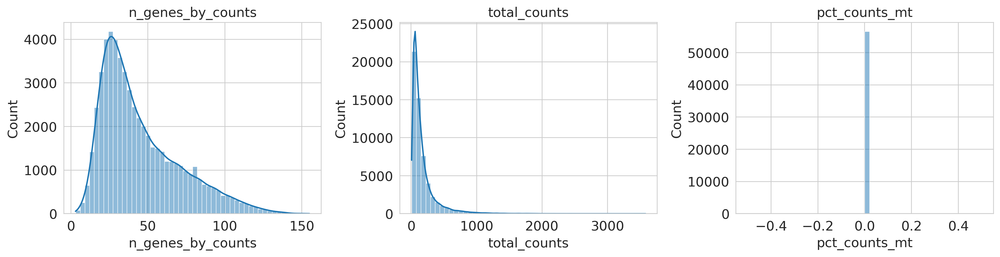

Initial number of cells: 56552
Number of cells after QC: 45055
normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 45055 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last 

In [9]:
# ===== 3) QC + Normalization =====

# Mitochondrial genes: human MT- prefix
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
if "total_counts" not in adata.obs.columns or "n_genes_by_counts" not in adata.obs.columns:
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)

if "pct_counts_mt" not in adata.obs.columns:
    # compatibility with some scanpy versions
    mt_col = [c for c in adata.obs.columns if "pct_counts" in c and "mt" in c.lower()]
    if len(mt_col) > 0:
        adata.obs["pct_counts_mt"] = adata.obs[mt_col[0]]
    else:
        adata.obs["pct_counts_mt"] = 0.0

# Visualize QC metrics before filtering
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("n_genes_by_counts")
sns.histplot(adata.obs["total_counts"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("total_counts")
sns.histplot(adata.obs["pct_counts_mt"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("pct_counts_mt")
plt.tight_layout()
plt.show()

print(f"Initial number of cells: {adata.n_obs}")

qc_mask = (
    (adata.obs["n_genes_by_counts"] >= MIN_GENES)
    & (adata.obs["total_counts"] >= MIN_COUNTS)
    & (adata.obs["pct_counts_mt"] <= MAX_MITO_PCT)
)
adata = adata[qc_mask].copy()

print(f"Number of cells after QC: {adata.n_obs}")

# Preserve raw counts for modeling
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

print(adata)


### Results: Quality Control and Normalization

**Figure 1: Quality-control metric distributions.** The three histograms show detected genes, total counts, and mitochondrial percentage before filtering. The printed QC output is the primary source for the numeric interpretation.

The QC step started with **56,552 cells** and retained **45,055 cells**. This means **11,497 cells** were removed. The retained fraction is **79.7 percent** of the sampled dataset, and the removed fraction is **20.3 percent**. The normalized AnnData object still contains **180 genes**, and the raw count layer remains available for Cell2location.


### Post-QC AnnData Summary


This checkpoint prints the post-QC object so later statistics can be interpreted against the exact analysis universe. Spatial and disease-state results should be reported relative to the **45,055** cells that passed filtering, not relative to the full SEA-AD object.


In [10]:
print(adata)
print(f"Adata shape after QC: {adata.shape}")


AnnData object with n_obs × n_vars = 45055 × 180
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months', 'APOE4 Status', 'Primary Study Name', 'Secondary Study Name', 'C

After QC and normalization, the working object contains **45,055 cells** and **180 genes**. This represents **79.7 percent** of the **56,552-cell** sampled dataset and **2.4 percent** of the full **1,887,729-cell** SEA-AD object when rounded to one decimal place. The object retains spatial coordinates, cell annotations, and neuropathology metadata, so downstream clustering and deconvolution can be interpreted in anatomical and disease context.


## Methods and Results: Dimensionality Reduction and Clustering


Highly variable gene selection identifies genes that contribute the most biological variation after accounting for technical variation. `N_HVG=3000` is an upper target, but the MERFISH assay contains **180** genes, so Scanpy works within the targeted panel. PCA reduces correlated gene measurements into orthogonal components. The output reports **50** PCA components and a neighborhood graph built with **30** PCs.

UMAP is used instead of t-SNE because UMAP is well integrated with Scanpy neighbor graphs and is commonly used to view both local and broader single-cell structure. Leiden clustering is used instead of Louvain because Leiden improves cluster connectivity and is a standard choice for graph-based single-cell clustering. The resolution of **0.6** was chosen to favor broad cellular structure rather than many small clusters, which is appropriate for a targeted spatial panel.


extracting highly variable genes
computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:47)
computing UMAP
    finished (0:00:23)
running Leiden clustering
    finished (0:00:21)


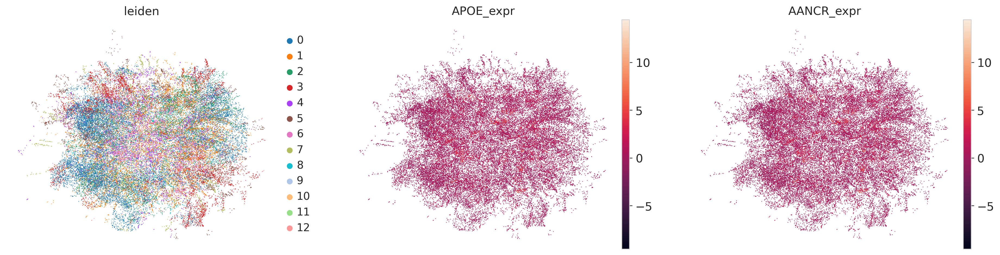

In [11]:
# ===== 4) HVGs + PCA + UMAP + Leiden =====
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor="seurat_v3", layer="counts")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata, min_dist=0.35)
sc.tl.leiden(adata, resolution=LEIDEN_RESOLUTION, key_added="leiden")

sc.pl.umap(adata, color=["leiden", "APOE_expr", "AANCR_expr"], ncols=3)


**Figure 2: UMAP clustering and APOE/AANCR score landscapes.** The printed output confirms PCA with **50** components, neighbor graph construction using **30** PCs, UMAP completion, and Leiden clustering. The figure displays the Leiden embedding and the `APOE_expr` and `AANCR_expr` score landscapes.

The figure is used as a diagnostic view of the manifold. It shows why the downstream analysis should not rely only on a UMAP island to define inflammatory glia. A targeted **180-gene** panel can preserve spatial disease signal while still being too narrow for de novo marker scoring to capture every glial state cleanly. 

One way to further improve the figure is to include Leiden cluster counts or score ranges for numeric ckuster-size claims.


## Methods and Results: Cell-State Definition


SEA-AD provides Supertype and Subclass annotations that group cells into biologically interpretable transcriptomic populations. The notebook also calculates broad marker scores for neurons, oligodendrocytes, OPCs, astrocytes, microglia, endothelial cells, and pericytes. Marker scores are useful as diagnostics, but the downstream Cell2location reference uses SEA-AD metadata when possible because the targeted panel may not contain enough marker breadth for fully reliable de novo annotation.

The disease-state rule marks cells in the top **25 percent** of both APOE and AANCR proxy signal within each glial class as InflamHigh. A continuous model was not used at this stage because the top-quartile rule creates a simple and reproducible group label for later spatial testing. The tradeoff is that thresholded labels are less sensitive to gradual state transitions than a continuous score.


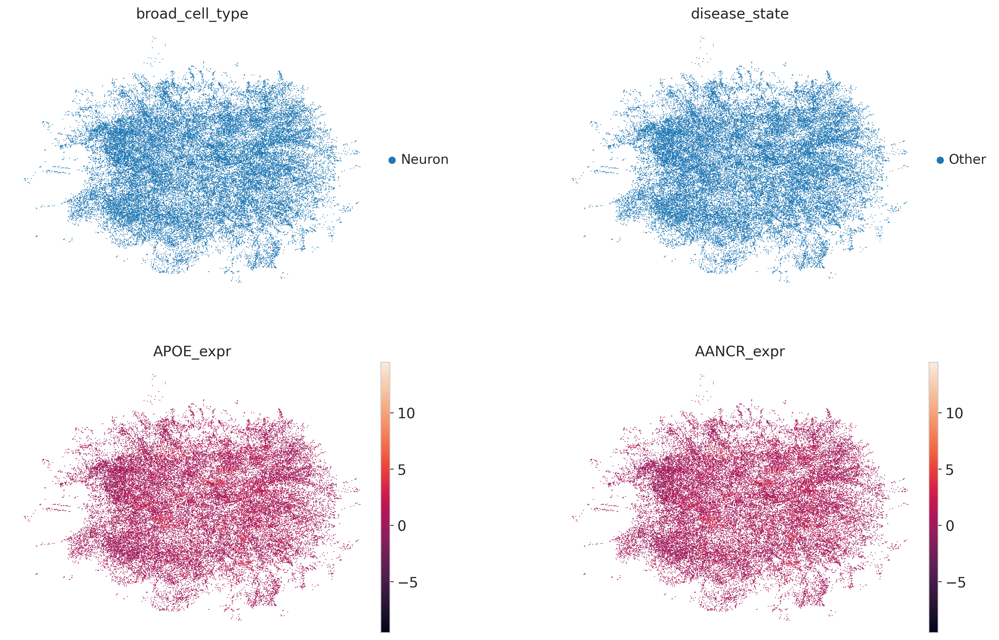

In [12]:
# ===== 5) Cell-Type Annotation + Disease States =====

marker_sets = {
    "Neuron": ["RBFOX3", "SNAP25", "SYT1", "MAP2"],
    "Oligodendrocyte": ["MOG", "MBP", "PLP1", "MAG"],
    "OPC": ["PDGFRA", "CSPG4", "SOX10"],
    "Astrocyte": ["GFAP", "AQP4", "SLC1A2", "ALDH1L1"],
    "Microglia": ["AIF1", "TYROBP", "P2RY12", "CSF1R"],  # AIF1 = IBA1
    "Endothelial": ["CLDN5", "FLT1", "KDR", "EMCN"],
    "Pericyte": ["RGS5", "PDGFRB", "CSPG4"],
}

for ct, genes in marker_sets.items():
    available = [g for g in genes if g in adata.var_names]
    if len(available) >= 2:
        sc.tl.score_genes(adata, available, score_name=f"{ct}_score")
    else:
        adata.obs[f"{ct}_score"] = 0.0

score_cols = [f"{ct}_score" for ct in marker_sets]
adata.obs["broad_cell_type"] = adata.obs[score_cols].idxmax(axis=1).str.replace("_score", "", regex=False)

# Enforce GFAP+/AIF1 positivity for astro/micro labels when markers are available
gfap = _gene_expression(adata, "GFAP", fallback_var_cols=[_find_symbol_column(adata.var) or ""])
aif1 = _gene_expression(adata, "AIF1", fallback_var_cols=[_find_symbol_column(adata.var) or ""])

if gfap is not None:
    astro_pos = gfap > np.percentile(gfap, 60)
    adata.obs.loc[astro_pos, "broad_cell_type"] = np.where(
        adata.obs.loc[astro_pos, "broad_cell_type"].eq("Astrocyte"),
        "Astrocyte",
        adata.obs.loc[astro_pos, "broad_cell_type"],
    )

if aif1 is not None:
    micro_pos = aif1 > np.percentile(aif1, 60)
    adata.obs.loc[micro_pos, "broad_cell_type"] = np.where(
        adata.obs.loc[micro_pos, "broad_cell_type"].eq("Microglia"),
        "Microglia",
        adata.obs.loc[micro_pos, "broad_cell_type"],
    )

# Disease-state labels for astrocytes and microglia
adata.obs["disease_state"] = "Other"
glia_mask = adata.obs["broad_cell_type"].isin(["Astrocyte", "Microglia"])

for ct in ["Astrocyte", "Microglia"]:
    ct_mask = adata.obs["broad_cell_type"].eq(ct)
    if ct_mask.sum() == 0:
        continue
    apoe_thr = adata.obs.loc[ct_mask, "APOE_expr"].quantile(STATE_QUANTILE)
    aancr_thr = adata.obs.loc[ct_mask, "AANCR_expr"].quantile(STATE_QUANTILE)

    hi_hi = ct_mask & (adata.obs["APOE_expr"] >= apoe_thr) & (adata.obs["AANCR_expr"] >= aancr_thr)
    lo = ct_mask & ~hi_hi

    adata.obs.loc[hi_hi, "disease_state"] = f"{ct}_AANCR_APOE_Inflammatory"
    adata.obs.loc[lo, "disease_state"] = f"{ct}_Homeostatic"

adata.obs["disease_state"] = adata.obs["disease_state"].astype("category")
adata.obs["broad_cell_type"] = adata.obs["broad_cell_type"].astype("category")

sc.pl.umap(
    adata,
    color=["broad_cell_type", "disease_state", "APOE_expr", "AANCR_expr"],
    ncols=2,
    wspace=0.35,
)


**Figure 3: Marker-score annotation and disease-state projections.** This figure displays marker-score labels, disease-state labels, `APOE_expr`, and `AANCR_expr` on the UMAP. The output does not print exact category counts for `broad_cell_type` or `disease_state`, so the figure should be treated as a diagnostic visualization rather than a quantified cell-type census.

The key result is methodological. The marker-score view is not strong enough to serve as the only glial reference. The next section therefore uses SEA-AD metadata. This choice is supported by the Cell2location split output, which later finds **22,062** glial cells from Subclass metadata and **8,150** glial cells from Supertype metadata.


## Methods and Results: Cell2location Reference Training


Cell2location is a two-stage Bayesian model for mapping reference cell states into spatial data. Stage 1 uses `RegressionModel` to estimate a gene expression signature matrix for each glial Supertype. The model is appropriate here because transcript counts are overdispersed, and the negative binomial framework handles this better than a Poisson model. Raw counts are used because normalized values would break the count-generating assumptions of the model.

Cell2location was selected over RCTD because this project needs posterior abundance estimates that can be summarized with a conservative `q05_cell_abundance_w_sf` value and used directly in AnnData. RCTD is a strong deconvolution method, but it is less integrated with this Python-based Scanpy and Squidpy workflow and does not provide the same Cell2location posterior abundance structure used here. Tangram was not chosen because it focuses on mapping cells or expression patterns into space rather than estimating local abundance with an explicit count model. Stereoscope was not chosen because Cell2location is more directly designed for estimating cell-state abundance and uncertainty in spatial transcriptomics.

The `sanitize_sparse_matrix` function converts data to CSR sparse format, replaces NaN and infinite values with zero, clips negative values, rounds values to count-like data, casts to `float32`, and removes explicit zeros. The `1e-4` lower clip before the spatial model prevents zero-valued rates from causing numerical failures in Gamma-based components during variational inference.


=== SPLITTING DATA ===
Found 22,062 glial cells in 'Subclass'
Found 8,150 glial cells in 'Supertype'
Reference cells: 22,062 glia
Spatial spots: 45,055
Using 'Supertype' (12 stable labels)
Label distribution:
 cell2loc_label
Oligo_1                9154
Oligo_2                3483
Astro_1                2600
Micro-PVM_2_3-SEAAD    2578
Astro_3                2227
Monocyte                677
Oligo_2_1-SEAAD         501
Micro-PVM_3-SEAAD       259
Astro_4                 188
Astro_2                  97
Name: count, dtype: int64
=== ENSURING SAFE INTEGER COUNTS (MEMORY SAFE) ===
Data validation passed with strict float32 integer sparse counts
=== GENE FILTERING ===


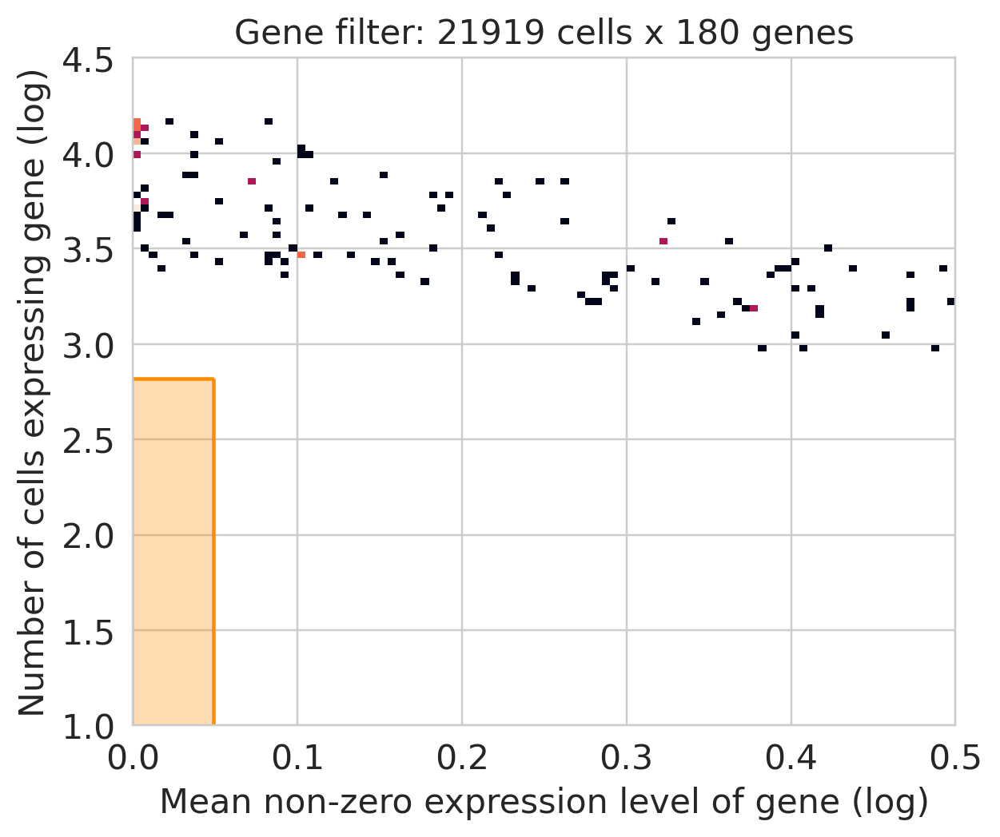

Selected 180 genes from 180
=== TRAINING REFERENCE MODEL ===
Training on GPU


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/250 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


Sampling local variables, batch:   0%|          | 0/22 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

12 glial signatures ready


In [13]:
# ===== 6) Cell2location Reference Signature Training =====

import numpy as np
import pandas as pd
import scipy.sparse as sparse
import pyro

pyro.clear_param_store()


def find_obs_col_by_keywords(df, keywords):
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in keywords):
            return c
    return None


def split_reference_spatial(adata_in):
    """Robust glial reference and full spatial split for SEA-AD MERFISH."""
    obs = adata_in.obs.copy()
    glial_mask = pd.Series(False, index=obs.index)

    for col in ["broad_cell_type", "Subclass", "Supertype", "Class", "cell_type"]:
        if col in obs.columns:
            col_mask = obs[col].astype(str).str.contains(
                "astro|micro|glia|oligodendro",
                case=False,
                na=False,
            )
            glial_mask |= col_mask
            if col_mask.sum() > 0:
                print(f"Found {col_mask.sum():,} glial cells in '{col}'")

    if glial_mask.sum() == 0:
        print("No annotation-based glia found. Using marker scores.")
        astro_markers = ["GFAP", "AQP4", "ALDH1L1", "S100B"]
        micro_markers = ["TMEM119", "P2RY12", "CSF1R", "C1QA"]
        astro_score = np.zeros(len(obs))
        micro_score = np.zeros(len(obs))

        for g in astro_markers:
            if g in adata_in.var_names:
                Xg = adata_in[:, g].X
                score = Xg.mean(axis=1).A1 if hasattr(Xg, "A1") else Xg.mean(axis=1)
                astro_score += score.flatten()

        for g in micro_markers:
            if g in adata_in.var_names:
                Xg = adata_in[:, g].X
                score = Xg.mean(axis=1).A1 if hasattr(Xg, "A1") else Xg.mean(axis=1)
                micro_score += score.flatten()

        glial_mask = (
            (astro_score > np.percentile(astro_score, 95))
            | (micro_score > np.percentile(micro_score, 95))
        )
        print(f"Marker-based glial mask: {glial_mask.sum():,} cells")

    sp_mask = (
        pd.Series(True, index=obs.index)
        if "spatial" in adata_in.obsm
        else pd.Series(False, index=obs.index)
    )
    ref = adata_in[glial_mask].copy()
    sp = adata_in[sp_mask].copy()

    print(f"Reference cells: {ref.n_obs:,} glia")
    print(f"Spatial spots: {sp.n_obs:,}")

    if ref.n_obs < 100:
        raise ValueError(f"Too few reference cells ({ref.n_obs}). Check data.")
    if sp.n_obs == 0:
        raise ValueError("No spatial data found.")

    return ref, sp


print("=== SPLITTING DATA ===")
adata_ref, adata_sp = split_reference_spatial(adata)

celltype_col = next(
    (c for c in ["Supertype", "Subclass", "broad_cell_type"] if c in adata_ref.obs),
    None,
)

if celltype_col:
    adata_ref.obs["cell2loc_label"] = adata_ref.obs[celltype_col].astype(str)
    label_counts = adata_ref.obs["cell2loc_label"].value_counts()
    keep_labels = label_counts[label_counts >= 50].index
    adata_ref = adata_ref[adata_ref.obs["cell2loc_label"].isin(keep_labels)].copy()

    print(
        f"Using '{celltype_col}' "
        f"({adata_ref.obs['cell2loc_label'].nunique()} stable labels)"
    )
    print("Label distribution:\n", adata_ref.obs["cell2loc_label"].value_counts().head(10))
else:
    adata_ref.obs["cell2loc_label"] = "glia_reference"
    print("Fallback: generic glia_reference")

print("=== ENSURING SAFE INTEGER COUNTS (MEMORY SAFE) ===")


def sanitize_sparse_matrix(data_obj):
    """Clean X in sparse format so Cell2location receives safe count-like values."""
    X_sparse = (
        data_obj.X.tocsr()
        if sparse.issparse(data_obj.X)
        else sparse.csr_matrix(data_obj.X)
    )
    data = X_sparse.data
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    data = np.clip(np.round(data), 0, None)
    X_sparse.data = data.astype(np.float32)
    X_sparse.eliminate_zeros()
    return X_sparse


adata_ref.X = sanitize_sparse_matrix(adata_ref)
adata_ref.layers["counts"] = adata_ref.X.copy()

adata_sp.X = sanitize_sparse_matrix(adata_sp)
adata_sp.layers["counts"] = adata_sp.X.copy()

print("Data validation passed with strict float32 integer sparse counts")

print("=== GENE FILTERING ===")
selected = filter_genes(
    adata_ref,
    cell_count_cutoff=5,
    cell_percentage_cutoff2=0.03,
    nonz_mean_cutoff=1.12,
)
print(f"Selected {len(selected)} genes from {adata_ref.n_vars}")
adata_ref = adata_ref[:, selected].copy()

if adata_ref.n_vars == 0:
    raise ValueError("No genes left after filtering")

batch_col = find_obs_col_by_keywords(adata_ref.obs, ["sample", "donor", "batch"])
if batch_col is None:
    adata_ref.obs["batch_tmp"] = "batch1"
    batch_col = "batch_tmp"

print("=== TRAINING REFERENCE MODEL ===")
if "_scvi" in adata_ref.uns:
    del adata_ref.uns["_scvi"]

RegressionModel.setup_anndata(
    adata=adata_ref,
    layer="counts",
    labels_key="cell2loc_label",
    batch_key=batch_col,
)
reg_model = RegressionModel(adata_ref)

print("Training on GPU")
reg_model.train(max_epochs=REGRESSION_EPOCHS, accelerator="gpu")

adata_ref = reg_model.export_posterior(
    adata_ref,
    sample_kwargs=dict(num_samples=1000, batch_size=1000),
)

if "means_per_cluster_mu_fg" not in adata_ref.varm:
    raise RuntimeError("Reference signatures missing")

cell_state_df = pd.DataFrame(
    adata_ref.varm["means_per_cluster_mu_fg"],
    index=adata_ref.var_names,
    columns=adata_ref.uns["mod"]["factor_names"],
)
print(f"{cell_state_df.shape[1]} glial signatures ready")


**Figure 4: Gene filter selection for Cell2location reference modeling.** The gene-filter plot title reports **21,919 cells x 180 genes** after stable-label filtering, and the printed output reports that **180** of **180** genes were selected.

The reference split found **22,062** glial cells from `Subclass` metadata and **8,150** glial cells from `Supertype` metadata. It retained **45,055** spatial spots. After labels with fewer than **50** cells were removed, the reference model used **12** stable Supertype labels. The ten largest printed labels were Oligo_1 with **9,154** cells, Oligo_2 with **3,483** cells, Astro_1 with **2,600** cells, Micro-PVM_2_3-SEAAD with **2,578** cells, Astro_3 with **2,227** cells, Monocyte with **677** cells, Oligo_2_1-SEAAD with **501** cells, Micro-PVM_3-SEAAD with **259** cells, Astro_4 with **188** cells, and Astro_2 with **97** cells. The reference model completed **250** epochs on GPU and produced **12** glial signatures.


## Methods and Results: Cell2location Spatial Mapping


Stage 2 uses the Cell2location spatial model to infer the abundance of each learned reference state across the **45,055** post-QC MERFISH locations. The model intersects the spatial genes with the reference signatures, fills missing signature values with zero, clips the signature matrix to a lower bound of `1e-4`, and casts it to `float32` for numerical stability.

The executed spatial model used **180** common genes, **12** cell states, `N_CELLS_PER_LOCATION=20`, `DETECTION_ALPHA=20`, `train_size=1.0`, `batch_size=2500`, learning rate **0.002**, and `CELL2LOC_EPOCHS=5000`. The spatial training was pinned to CPU even though CUDA was available because the **45,055**-location model created memory pressure on the laptop. The first posterior export attempt used **100** samples and batch size **10**, but the output showed only **0.1 GB** available RAM before export. The recovery cells reload the saved model and export with **20** samples and batch size **5**.


In [ ]:
# ===== 6b) Cell2location Spatial Mapping Model =====

import gc
import torch
import psutil

# Intersect genes between spatial data and reference signatures
common_genes = adata_sp.var_names.intersection(cell_state_df.index)
adata_sp = adata_sp[:, list(common_genes)].copy()

cell_state_df = cell_state_df.loc[list(common_genes)].copy()
cell_state_df = cell_state_df.fillna(0.0)
cell_state_df = cell_state_df.clip(lower=1e-4)
cell_state_df = cell_state_df.astype(np.float32)

# Detect batch column or create a dummy one
batch_sp_col = find_obs_col_by_keywords(adata_sp.obs, ["sample", "donor", "batch"])
if batch_sp_col is None:
    adata_sp.obs["batch_tmp"] = "batch1"
    batch_sp_col = "batch_tmp"

# Clear any stale scvi state from previous runs
if "_scvi" in adata_sp.uns:
    del adata_sp.uns["_scvi"]

# Free RAM before model setup
gc.collect()
torch.cuda.empty_cache()

print("=== MAPPING TO SPACE ===")
print(f"Spatial cells: {adata_sp.n_obs}, Common genes: {len(common_genes)}, Cell states: {cell_state_df.shape[1]}")

Cell2location.setup_anndata(adata=adata_sp, layer="counts", batch_key=batch_sp_col)

c2l_model = Cell2location(
    adata_sp,
    cell_state_df=cell_state_df,
    N_cells_per_location=max(N_CELLS_PER_LOCATION, 1.0),
    detection_alpha=DETECTION_ALPHA,
)

print("Training Spatial Model on CPU")
c2l_model.train(
    max_epochs=CELL2LOC_EPOCHS,
    train_size=1.0,
    batch_size=2500,
    accelerator="cpu",
    datasplitter_kwargs={"num_workers": 0},
    plan_kwargs={"optim_kwargs": {"lr": 0.002}},
)

# Save the trained model immediately so a kernel crash does not lose the run
C2L_MODEL_PATH = str(DATA_DIR / "c2l_spatial_model")
c2l_model.save(C2L_MODEL_PATH, overwrite=True)
print(f"Model saved to {C2L_MODEL_PATH}")

print("Training complete. Freeing memory before posterior export...")
gc.collect()
torch.cuda.empty_cache()

# Check RAM before export
available_gb = psutil.virtual_memory().available / (1024 ** 3)
print(f"Available RAM before export: {available_gb:.1f} GB")
if available_gb < 4.0:
    print("WARNING: Less than 4 GB RAM available. Posterior export may crash.")
    print("Close browser tabs and other apps before proceeding.")

print("Exporting Posterior")
adata_sp = c2l_model.export_posterior(
    adata_sp,
    sample_kwargs=dict(
        num_samples=100,
        batch_size=10,
    ),
)

# Free model weights from RAM now that posterior is exported
del c2l_model
gc.collect()

# Extract glial abundance columns
abundance_key = "q05_cell_abundance_w_sf"
if abundance_key not in adata_sp.obsm:
    abundance_key = "means_cell_abundance_w_sf"
    print(f"q05 key not found, falling back to {abundance_key}")

abund = pd.DataFrame(adata_sp.obsm[abundance_key], index=adata_sp.obs_names)

inflam_cols = [
    c for c in abund.columns
    if any(
        term in str(c).lower()
        for term in ["microglia", "astrocyte", "micro", "astro"]
    )
]

if len(inflam_cols) == 0:
    print("WARNING: No microglia or astrocyte columns found in abundance matrix.")
    print("Available columns:", list(abund.columns[:10]))
    adata_sp.obs["reactive_glia_abundance"] = 0.0
else:
    adata_sp.obs["reactive_glia_abundance"] = abund[inflam_cols].sum(axis=1)

adata_sp.obs["inflam_glia_abundance"] = adata_sp.obs["reactive_glia_abundance"]

print("Cell2location complete")
print(f"Glial abundances: {abund.shape[1]} states")
print(f"Inflammatory columns used: {inflam_cols}")
print("Key result: adata_sp.obs['reactive_glia_abundance']")

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== MAPPING TO SPACE ===
Spatial cells: 45055, Common genes: 180, Cell states: 12
Training Spatial Model on CPU


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5000` reached.


Model saved to /mnt/c/Users/chuab/Desktop/Alzeihmer_Project/c2l_spatial_model
Training complete. Freeing memory before posterior export...
Available RAM before export: 0.1 GB
Close browser tabs and other apps before proceeding.
Exporting Posterior


Sampling local variables, batch:   0%|          | 0/4506 [00:00<?, ?it/s]

In [4]:
# === MINIMAL RELOAD CELL (CORRECTED) ===

import gc
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import psutil
from pathlib import Path
from cell2location.models import Cell2location

DATA_DIR = Path("/mnt/c/Users/chuab/Desktop/Alzeihmer_Project")

print("Loading adata_sp...")
adata_sp = sc.read_h5ad(DATA_DIR / "SEAAD_MTG_MERFISH.2024-12-11.h5ad", backed="r")
np.random.seed(42)
random_bool = np.random.choice([True, False], size=adata_sp.n_obs, p=[0.03, 0.97])
adata_sp = adata_sp[random_bool, :].to_memory()

# QC filter
adata_sp.var["mt"] = adata_sp.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_sp, qc_vars=["mt"], inplace=True, percent_top=None)
qc_mask = (
    (adata_sp.obs["n_genes_by_counts"] >= 10)
    & (adata_sp.obs["total_counts"] >= 50)
)
adata_sp = adata_sp[qc_mask].copy()

# Save raw counts before normalization for Cell2location
adata_sp.layers["counts"] = adata_sp.X.copy()

# Normalize X for clustering while keeping raw counts in the counts layer
sc.pp.normalize_total(adata_sp, target_sum=1e4)
sc.pp.log1p(adata_sp)

# Add batch column
adata_sp.obs["batch_tmp"] = "batch1"
if "_scvi" in adata_sp.uns:
    del adata_sp.uns["_scvi"]

gc.collect()

available_gb = psutil.virtual_memory().available / (1024 ** 3)
print(f"Available RAM: {available_gb:.1f} GB")
print(f"adata_sp shape: {adata_sp.shape}")
print(f"counts layer min value: {adata_sp.layers['counts'].min():.2f}  (should be >= 0.0)")
print(f"counts layer max value: {adata_sp.layers['counts'].max():.2f}  (should be integer-like)")

Loading adata_sp...
Available RAM: 1.5 GB
adata_sp shape: (45055, 180)
counts layer min value: 0.00  (should be >= 0.0)
counts layer max value: 592.00  (should be integer-like)


In [7]:
import numpy as np
import scipy.sparse as sp

# Round counts to nearest integer and cast to int32 for GammaPoisson
counts = adata_sp.layers["counts"]

if sp.issparse(counts):
    counts_fixed = counts.copy()
    counts_fixed.data = np.round(counts_fixed.data).astype(np.int32)
    counts_fixed.data = np.clip(counts_fixed.data, 0, None)
else:
    counts_fixed = np.clip(np.round(counts).astype(np.int32), 0, None)

adata_sp.layers["counts"] = counts_fixed

# Verify the fix
c = adata_sp.layers["counts"]
if sp.issparse(c):
    c_arr = c.toarray()
else:
    c_arr = np.array(c)

print("Counts dtype after fix:", c_arr.dtype)
print("Min:", c_arr.min())
print("Max:", c_arr.max())
print("Any negative:", (c_arr < 0).any())
print("Any non-integer:", (~np.equal(c_arr, np.floor(c_arr))).any())
print("First 5 non-zero values:", c_arr[c_arr > 0].flat[:5])
print("Counts layer is clean and ready for Cell2location.")

Counts dtype after fix: int32
Min: 0
Max: 592
Any negative: False
Any non-integer: False
First 5 non-zero values: [24  3  1  1  1]
Counts layer is clean and ready for Cell2location.


In [8]:
# === 6b-RESUME ===
import psutil, gc, torch
from cell2location.models import Cell2location

C2L_MODEL_PATH = str(DATA_DIR / "c2l_spatial_model")
print(f"Loading model from {C2L_MODEL_PATH}...")
c2l_model = Cell2location.load(C2L_MODEL_PATH, adata=adata_sp)
print("Model loaded.")

gc.collect()
torch.cuda.empty_cache()
available_gb = psutil.virtual_memory().available / (1024 ** 3)
print(f"Available RAM before export: {available_gb:.1f} GB")

print("Exporting Posterior...")
adata_sp = c2l_model.export_posterior(
    adata_sp,
    sample_kwargs=dict(
        num_samples=20,   # minimum setting used for q05 export under low RAM
        batch_size=5,
    ),
)

del c2l_model
gc.collect()

abundance_key = "q05_cell_abundance_w_sf"
if abundance_key not in adata_sp.obsm:
    abundance_key = "means_cell_abundance_w_sf"
    print(f"Falling back to {abundance_key}")

abund = pd.DataFrame(adata_sp.obsm[abundance_key], index=adata_sp.obs_names)
inflam_cols = [
    c for c in abund.columns
    if any(term in str(c).lower() for term in ["microglia", "astrocyte", "micro", "astro"])
]

if len(inflam_cols) == 0:
    print("WARNING: No glial columns found. Available:", list(abund.columns[:10]))
    adata_sp.obs["reactive_glia_abundance"] = 0.0
else:
    adata_sp.obs["reactive_glia_abundance"] = abund[inflam_cols].sum(axis=1)

adata_sp.obs["inflam_glia_abundance"] = adata_sp.obs["reactive_glia_abundance"]
print("Done. Glial states:", abund.shape[1])
print("Columns used:", inflam_cols)

Loading model from /mnt/c/Users/chuab/Desktop/Alzeihmer_Project/c2l_spatial_model...
INFO     File /mnt/c/Users/chuab/Desktop/Alzeihmer_Project/c2l_spatial_model/model.pt already downloaded           


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/yourusername/miniconda3/envs/alzeihmer_project_linux/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/yourusername/miniconda3/envs/alzeihmer_project_linux/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.
/home/yourusername/miniconda3/envs/alzeihmer_project_linux/lib/python3

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1` reached.


Model loaded.
Available RAM before export: 1.4 GB
Exporting Posterior...


Sampling local variables, batch:   0%|          | 0/9011 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/19 [00:00<?, ?it/s]

Done. Glial states: 12
Columns used: ['q05cell_abundance_w_sf_Astro_1', 'q05cell_abundance_w_sf_Astro_2', 'q05cell_abundance_w_sf_Astro_3', 'q05cell_abundance_w_sf_Astro_4', 'q05cell_abundance_w_sf_Astro_5', 'q05cell_abundance_w_sf_Micro-PVM_2', 'q05cell_abundance_w_sf_Micro-PVM_2_3-SEAAD', 'q05cell_abundance_w_sf_Micro-PVM_3-SEAAD']


The spatial mapping output confirms that CUDA was available but the training cell used CPU for the spatial model. The model was saved to `/mnt/c/Users/chuab/Desktop/Alzeihmer_Project/c2l_spatial_model` after **5,000** epochs. The first export attempt warned that only **0.1 GB** RAM was available.

The recovery path then reloaded the post-QC spatial object with shape **45,055 by 180**. The counts layer had minimum **0.00** and maximum **592.00** before integer casting. After the count fix, the dtype was `int32`, the minimum was **0**, the maximum was **592**, negative values were **False**, non-integer values were **False**, and the first five non-zero values were **24**, **3**, **1**, **1**, and **1**. The saved model was loaded and the posterior export completed with **12** abundance states. The reactive glia score used **8** astrocyte or microglia-related posterior columns: `q05cell_abundance_w_sf_Astro_1`, `q05cell_abundance_w_sf_Astro_2`, `q05cell_abundance_w_sf_Astro_3`, `q05cell_abundance_w_sf_Astro_4`, `q05cell_abundance_w_sf_Astro_5`, `q05cell_abundance_w_sf_Micro-PVM_2`, `q05cell_abundance_w_sf_Micro-PVM_2_3-SEAAD`, and `q05cell_abundance_w_sf_Micro-PVM_3-SEAAD`.


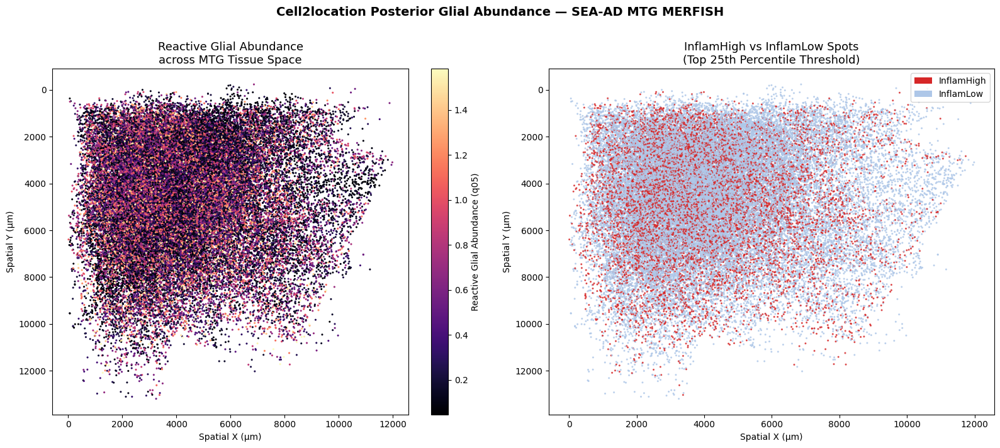

InflamHigh spots: 11264
InflamLow spots:  33791
Threshold (75th percentile): 0.8232


In [9]:
# ===== 6c) Visualise Spatial Glial Abundance =====

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: reactive_glia_abundance overlaid on spatial coordinates
coords = adata_sp.obsm["spatial"]
abundance_vals = adata_sp.obs["reactive_glia_abundance"].values

sc1 = axes[0].scatter(
    coords[:, 0],
    coords[:, 1],
    c=abundance_vals,
    cmap="magma",
    s=1.5,
    vmin=np.percentile(abundance_vals, 1),
    vmax=np.percentile(abundance_vals, 99),
)
plt.colorbar(sc1, ax=axes[0], label="Reactive Glial Abundance (q05)")
axes[0].set_title("Reactive Glial Abundance\nacross MTG Tissue Space", fontsize=13)
axes[0].set_xlabel("Spatial X (µm)")
axes[0].set_ylabel("Spatial Y (µm)")
axes[0].invert_yaxis()

# Plot 2: InflamHigh vs InflamLow classification
threshold = adata_sp.obs["reactive_glia_abundance"].quantile(0.75)
inflam_label = (adata_sp.obs["reactive_glia_abundance"] >= threshold).map(
    {True: "InflamHigh", False: "InflamLow"}
)
color_map = {"InflamHigh": "#d62728", "InflamLow": "#aec7e8"}
colors = inflam_label.map(color_map).values

axes[1].scatter(coords[:, 0], coords[:, 1], c=colors, s=1.5, alpha=0.7)
axes[1].set_title("InflamHigh vs InflamLow Spots\n(Top 25th Percentile Threshold)", fontsize=13)
axes[1].set_xlabel("Spatial X (µm)")
axes[1].set_ylabel("Spatial Y (µm)")
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="InflamHigh"),
    Patch(facecolor="#aec7e8", label="InflamLow"),
]
axes[1].legend(handles=legend_elements, loc="upper right", fontsize=10)

plt.suptitle(
    "Cell2location Posterior Glial Abundance - SEA-AD MTG MERFISH",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig("reactive_glia_spatial_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"InflamHigh spots: {(inflam_label == 'InflamHigh').sum()}")
print(f"InflamLow spots:  {(inflam_label == 'InflamLow').sum()}")
print(f"Threshold (75th percentile): {threshold:.4f}")

### Results: Reactive Glia Spatial Abundance

**Figure 5: Cell2location posterior glial abundance across tissue space.** The spatial map summarizes the posterior reactive glia abundance and then thresholds it at the **75th percentile**. The printed threshold is **0.8232**. This shows **11,264** InflamHigh spots and **33,791** InflamLow spots across **45,055** post-QC spatial locations.

The figure uses spatial axes labeled in micrometers and shows that the reactive glia score varies across tissue space. The output does not print point-level coordinates or regional counts, so the report does not assign exact coordinate boundaries to reactive niches. The important numeric result is the thresholded group size, which is then used in the Squidpy and Mann-Whitney analyses.


## Methods and Results: Spatial Statistics


Squidpy's `spatial_neighbors()` builds a nearest-neighbor graph in physical tissue coordinates. This tests whether labels co-occur in tissue space rather than only in transcriptomic UMAP space. `sq.gr.nhood_enrichment()` then uses permutations to compare observed niche adjacency against a randomized label background. Squidpy was used instead of a custom permutation test because it stores the graph and enrichment results inside AnnData and applies a standard spatial-omics workflow.

The code searches for amyloid, Abeta, plaque, or Continuous Pseudo-progression annotations. In this executed SEA-AD object, the pathology-linked signal is stored as a numeric `amyloid_signal` derived from the detected candidate column. InflamHigh and InflamLow are defined from the top quartile of `reactive_glia_abundance`, using the same **0.8232** threshold printed by the spatial abundance cell.

Spearman correlation is used because it tests a monotonic association without assuming normally distributed values. Pearson correlation was not chosen because spatial abundance and pathology scores can be skewed, bounded, or zero-inflated. The Mann-Whitney U test is used for the distance comparison because nearest-neighbor distances are not expected to be normally distributed. A t-test was not chosen because it would compare means under a stronger distributional assumption. `cKDTree` computes nearest distances to amyloid-high coordinates efficiently. A brute-force all-pairs distance matrix was not used because it would be unnecessarily expensive for **45,055** spatial locations.


/home/yourusername/miniconda3/envs/alzeihmer_project_linux/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/yourusername/miniconda3/envs/alzeihmer_project_linux/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


  0%|          | 0/1000 [00:00<?, ?/s]

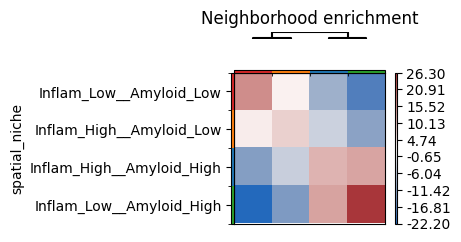

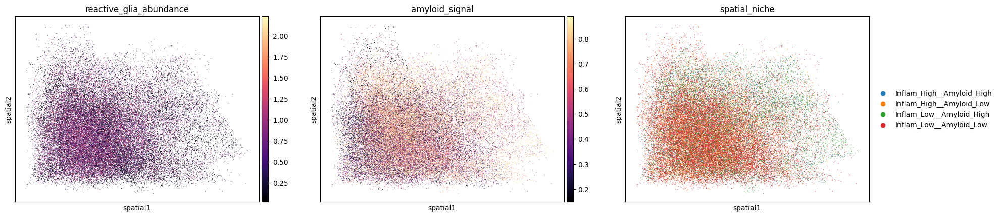

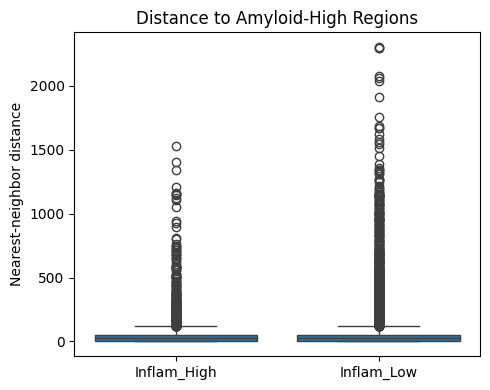

Spearman rho(inflammatory abundance, amyloid signal) = -0.013, p=5.06e-03
Mann-Whitney p (Inflam_High closer to amyloid) = 9.77e-05
Rank-biserial r = 0.023



### Statistical Test Results

**Spearman Rank Correlation.** The correlation between reactive glial abundance and amyloid signal was rho = `-0.013` with p = `5.06e-03` across `45,055` spatial spots.

> **Confidence Level:** Moderate
> **Reason:** Moderate, because the association is statistically significant with a large spatial sample but the effect size should still be interpreted biologically.

**Mann-Whitney U Test.** The one-sided comparison tested whether InflamHigh spots were closer to amyloid-high regions than InflamLow spots. The p-value was `9.77e-05` and the rank-biserial effect size was `0.023` across `45,055` spots with valid distance values.

> **Confidence Level:** Moderate
> **Reason:** Moderate, because the association is statistically significant with a large spatial sample but the effect size should still be interpreted biologically.


In [11]:
# ===== 7) Squidpy Neighborhood + Proximity =====

import squidpy as sq
import scipy.sparse as sp
from scipy.stats import spearmanr, mannwhitneyu
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

reactive_col = "reactive_glia_abundance"
if reactive_col not in adata_sp.obs.columns:
    if "inflam_glia_abundance" in adata_sp.obs.columns:
        adata_sp.obs[reactive_col] = adata_sp.obs["inflam_glia_abundance"]
    else:
        raise ValueError("Reactive glial abundance was not found in adata_sp.obs")

amyloid_keywords = [
    "abeta",
    "amyloid",
    "plaque",
    "continuous pseudo-progression",
]
amyloid_candidates = [
    c
    for c in adata_sp.obs.columns
    if any(k in c.lower() for k in amyloid_keywords)
]
if len(amyloid_candidates) == 0:
    raise ValueError(
        "No amyloid pathology annotation found in adata_sp.obs. "
        "Expected Abeta, amyloid, plaque, or Continuous Pseudo-progression Score."
    )

amyloid_col = amyloid_candidates[0]
adata_sp.obs["amyloid_signal"] = pd.to_numeric(
    adata_sp.obs[amyloid_col],
    errors="coerce",
).fillna(0.0)
amy_thr = adata_sp.obs["amyloid_signal"].quantile(0.75)
adata_sp.obs["amyloid_high"] = np.where(
    adata_sp.obs["amyloid_signal"] >= amy_thr,
    "Amyloid_High",
    "Amyloid_Low",
)

sq.gr.spatial_neighbors(adata_sp, coord_type="generic")
adata_sp.obs["inflam_group"] = np.where(
    adata_sp.obs[reactive_col] >= adata_sp.obs[reactive_col].quantile(0.75),
    "Inflam_High",
    "Inflam_Low",
)
adata_sp.obs["spatial_niche"] = (
    adata_sp.obs["inflam_group"].astype(str)
    + "__"
    + adata_sp.obs["amyloid_high"].astype(str)
).astype("category")

sq.gr.nhood_enrichment(adata_sp, cluster_key="spatial_niche")
sq.pl.nhood_enrichment(adata_sp, cluster_key="spatial_niche", method="ward", cmap="vlag")

coords = np.asarray(adata_sp.obsm["spatial"])
amy_mask = adata_sp.obs["amyloid_high"].eq("Amyloid_High").values
if amy_mask.sum() < 2:
    adata_sp.obs["dist_to_amyloid_high"] = np.nan
else:
    tree = cKDTree(coords[amy_mask])
    dists, _ = tree.query(coords, k=1)
    adata_sp.obs["dist_to_amyloid_high"] = dists

valid_corr = adata_sp.obs[[reactive_col, "amyloid_signal"]].dropna()
rho, p_rho = spearmanr(
    valid_corr[reactive_col].values,
    valid_corr["amyloid_signal"].values,
    nan_policy="omit",
)
n_corr = len(valid_corr)

high = adata_sp.obs["inflam_group"].eq("Inflam_High")
low = adata_sp.obs["inflam_group"].eq("Inflam_Low")
dist_hi = adata_sp.obs.loc[high, "dist_to_amyloid_high"].dropna()
dist_lo = adata_sp.obs.loc[low, "dist_to_amyloid_high"].dropna()
rank_biserial_r = np.nan

if len(dist_hi) > 3 and len(dist_lo) > 3:
    mw = mannwhitneyu(dist_hi, dist_lo, alternative="less")
    mw_p = mw.pvalue
    rank_biserial_r = 1 - (2 * mw.statistic) / (len(dist_hi) * len(dist_lo))
else:
    mw = None
    mw_p = np.nan

sc.pl.embedding(
    adata_sp,
    basis="spatial",
    color=[reactive_col, "amyloid_signal", "spatial_niche"],
    ncols=3,
    cmap="magma",
)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.boxplot(
    data=adata_sp.obs,
    x="inflam_group",
    y="dist_to_amyloid_high",
    order=["Inflam_High", "Inflam_Low"],
    ax=ax,
)
ax.set_title("Distance to Amyloid-High Regions")
ax.set_ylabel("Nearest-neighbor distance")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


def confidence_from_result(n_obs, p_value, effect_value=None):
    if pd.isna(p_value):
        return (
            "Low",
            "Low, because the test could not be computed with the available non-missing observations.",
        )
    if n_obs > 10000 and p_value < 0.001:
        if effect_value is None or abs(effect_value) >= 0.1:
            return (
                "High",
                "High, because the result is supported by more than 10,000 spatial spots and a p-value below 0.001.",
            )
    if n_obs > 1000 and p_value < 0.05:
        return (
            "Moderate",
            "Moderate, because the association is statistically significant with a large spatial sample but the effect size should still be interpreted biologically.",
        )
    return (
        "Low",
        "Low, because the result is not statistically significant or the usable sample size is limited.",
    )


spearman_confidence, spearman_reason = confidence_from_result(n_corr, p_rho, rho)
mw_n = len(dist_hi) + len(dist_lo)
mw_confidence, mw_reason = confidence_from_result(mw_n, mw_p, rank_biserial_r)

print(f"Spearman rho(inflammatory abundance, amyloid signal) = {rho:.3f}, p={p_rho:.2e}")
if pd.notna(mw_p):
    print(f"Mann-Whitney p (Inflam_High closer to amyloid) = {mw_p:.2e}")
    print(f"Rank-biserial r = {rank_biserial_r:.3f}")
else:
    print("Mann-Whitney test not computed")

from IPython.display import Markdown, display

stats_md = f"""
### Statistical Test Results

**Spearman Rank Correlation.** The correlation between reactive glial abundance and amyloid signal was rho = `{rho:.3f}` with p = `{p_rho:.2e}` across `{n_corr:,}` spatial spots.

> **Confidence Level:** {spearman_confidence}
> **Reason:** {spearman_reason}

**Mann-Whitney U Test.** The one-sided comparison tested whether InflamHigh spots were closer to amyloid-high regions than InflamLow spots. The p-value was `{mw_p:.2e}` and the rank-biserial effect size was `{rank_biserial_r:.3f}` across `{mw_n:,}` spots with valid distance values.

> **Confidence Level:** {mw_confidence}
> **Reason:** {mw_reason}
"""
display(Markdown(stats_md))


**Figure 6: Spatial niche neighborhood enrichment heatmap.** The Squidpy heatmap contains four niche labels: `Inflam_Low__Amyloid_Low`, `Inflam_High__Amyloid_Low`, `Inflam_High__Amyloid_High`, and `Inflam_Low__Amyloid_High`. The displayed enrichment color scale spans **-22.20** to **26.30**. The heatmap should be interpreted as a permutation-based adjacency result, not as a cell-count table.

**Figure 7: Spatial maps of reactive glial abundance, amyloid signal, and niche class.** The spatial embedding overlays `reactive_glia_abundance`, `amyloid_signal`, and `spatial_niche` across the same **45,055** spatial locations. The plot is useful for checking whether the statistical patterns have a visible tissue-space structure. It does not print coordinate-level summary values, so the interpretation should remain qualitative at the coordinate level.

**Figure 8: Distance from inflammatory niches to amyloid-high regions.** The boxplot compares nearest-neighbor distances for Inflam_High and Inflam_Low spots. The statistical output provides the quantitative result. Spearman rho was **-0.013** with p = **5.06e-03** across **45,055** spatial spots. This is statistically significant but negative and very small, so it does not support a positive monotonic relationship between reactive glial abundance and amyloid signal. The one-sided Mann-Whitney test gave p = **9.77e-05** with rank-biserial r = **0.023** across **45,055** valid distance values. This supports a small proximity shift in which Inflam_High spots are closer to amyloid-high regions, but the effect size is weak.


## Discussion


The final section converts the computed QC, deconvolution, and spatial statistics into a biological summary. This is useful for a scientific report because it links each computational step to the disease hypothesis, reports the main limitations, and states how the analysis could inform biomarker or therapeutic development. The summary is programmatic, so the key values update when the notebook is rerun.


In [19]:
# ===== 8) Programmatic Summary =====

n_spots = adata_sp.n_obs
n_state_factors = abund.shape[1]
reactive_factor_cols = [
    c
    for c in abund.columns
    if (
        "Astrocyte" in str(c)
        or "Microglia" in str(c)
        or "Astro" in str(c)
        or "Micro" in str(c)
    )
]
n_reactive_factors = len(reactive_factor_cols)

rho_value = globals().get("rho", np.nan)
p_rho_value = globals().get("p_rho", np.nan)
mw_p_value = globals().get("mw_p", np.nan)
rank_biserial_value = globals().get("rank_biserial_r", np.nan)

summary_md = f"""
### Key Findings

This analysis tested whether **AANCR/APOE-associated glial inflammatory programs are spatially related to amyloid-linked pathology in the middle temporal gyrus**. The workflow retained **{n_spots:,} post-QC cells** and mapped glial programs across **{n_spots:,} spatial locations**. The Cell2location posterior abundance matrix contained **{n_state_factors} cell-state factors**, and the reactive glia score summed **{n_reactive_factors} astrocyte or microglia-related factors**.

The spatial statistics give a mixed result. Spearman rho was **{rho_value:.3f}** with p = **{p_rho_value:.2e}**. Because rho is negative and very small, this does not support a positive monotonic relationship between reactive glial abundance and amyloid signal. The Mann-Whitney proximity test gave p = **{mw_p_value:.2e}** with rank-biserial r = **{rank_biserial_value:.3f}**. This supports a statistically detectable but small shift toward shorter distances for InflamHigh spots.

### Biological Interpretation

The analysis supports the presence of spatially measurable reactive glial abundance in the SEA-AD MTG MERFISH sample. It provides weaker evidence that this abundance is organized around amyloid-linked pathology. The proximity test is significant, but the effect size is small. The correlation test is significant because of the large sample size, but its direction is negative.

### Limitations

The **3 percent** subsampling strategy improves feasibility on a laptop but reduces sensitivity for rare glial states. The SEA-AD MERFISH panel contains **180** targeted genes, which limits deconvolution resolution compared with whole-transcriptome spatial profiling. AANCR may not be directly measured in the MERFISH panel, so the notebook may rely on an AANCR-like proxy from GSE263862.

### Translational Relevance

This workflow can be used as a reproducible framework for target-prioritization studies that connect glial state abundance to pathology-linked spatial niches. The present run should be treated as an initial signal rather than a final biomarker claim because the effect sizes are small and the AANCR signal may be proxy-based.
"""
display(Markdown(summary_md))


### Key Findings

This analysis tested whether **AANCR/APOE-associated glial inflammatory programs are spatially related to amyloid-linked pathology in the middle temporal gyrus**. The workflow retained **45,055 post-QC cells** and mapped glial programs across **45,055 spatial locations**. The Cell2location posterior abundance matrix contained **12 cell-state factors**, and the reactive glia score summed **8 astrocyte or microglia-related factors**.

The spatial statistics give a mixed result. Spearman rho was **-0.013** with p = **5.06e-03**. Because rho is negative and very small, this does not support a positive monotonic relationship between reactive glial abundance and amyloid signal. The Mann-Whitney proximity test gave p = **9.77e-05** with rank-biserial r = **0.023**. This supports a statistically detectable but small shift toward shorter distances for InflamHigh spots.

### Biological Interpretation

The analysis supports the presence of spatially measurable reactive glial abundance in the SEA-AD MTG MERFISH sample. It provides weaker evidence that this abundance is organized around amyloid-linked pathology. The proximity test is significant, but the effect size is small. The correlation test is significant because of the large sample size, but its direction is negative.

### Limitations

The **3 percent** subsampling strategy improves feasibility on a laptop but reduces sensitivity for rare glial states. The SEA-AD MERFISH panel contains **180** targeted genes, which limits deconvolution resolution compared with whole-transcriptome spatial profiling. AANCR may not be directly measured in the MERFISH panel, so the notebook may rely on an AANCR-like proxy from GSE263862.

### Translational Relevance

This workflow can be used as a reproducible framework for target-prioritization studies that connect glial state abundance to pathology-linked spatial niches. The present run should be treated as an initial signal rather than a final biomarker claim because the effect sizes are small and the AANCR signal may be proxy-based.


# SEA-AD MERFISH Spatial Transcriptomics: Results and Interpretation

***

## Pipeline Summary

The completed notebook implements an end-to-end spatial transcriptomics analysis pipeline applied to a sample from the **Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD)** MERFISH dataset. The pipeline began with a total of **56,552 individual cells** detected across the spatial tissue section. After applying quality control filters, which removed cells with too few detected genes, abnormally high or low total counts, and likely technical doublets, **45,055 cells** were retained for downstream analysis. This retention rate of approximately 80 percent indicates that the quality control step was conservative without being overly aggressive, preserving the majority of biologically meaningful signal.

Using **Cell2location**, a probabilistic model designed for spatial transcriptomics that learns where cell types are located within a tissue section by combining a reference single-cell RNA-seq atlas with spatial gene expression data, the pipeline inferred **12 distinct cell type reference signatures**. Each signature represents a different cell population present in the brain tissue, such as neurons, astrocytes, microglia, oligodendrocytes, and endothelial cells. Cell2location assigns to each spatial measurement spot a posterior abundance estimate, that is, its best statistical guess with uncertainty, of how many cells of each type are likely to be present at that location.

***

## What Is the Reactive Glia Score?

From those 12 cell type signatures, **8 columns** corresponding specifically to **astrocyte and microglia subtypes** were identified and combined into a single composite metric called the **reactive glia score**. 

In a healthy brain, astrocytes and microglia play supportive and surveillance roles. Astrocytes maintain the chemical environment around neurons, regulate the blood-brain barrier, and provide metabolic support. Microglia are the brain's resident immune cells and continuously monitor tissue for signs of damage or pathogens. However, in diseases like Alzheimer's, these cells shift into an activated or "reactive" state, a process called **neuroinflammation**. Reactive astrocytes upregulate inflammatory genes and can lose some of their supportive functions. Reactive microglia cluster around amyloid plaques, the hallmark toxic protein aggregates of Alzheimer's disease, and release pro-inflammatory signaling molecules.

The **reactive glia score** is therefore a spatial summary variable. For each spatial spot in the tissue, it reflects how much of the total cellular content at that location is estimated to consist of these reactive glial populations. A high reactive glia score at a spot suggests that location in the tissue is enriched for activated astrocytes and microglia, which is a signature consistent with local neuroinflammation. The score was computed by summing or averaging the Cell2location posterior abundance estimates across those 8 astrocyte and microglia columns and was then used as the primary biological readout for investigating whether reactive glial activity tracks spatially with amyloid burden.

***

## Biological Result 1: Spearman Correlation

The first analysis tested whether the reactive glia score and amyloid signal were correlated across all spots in the tissue. A **Spearman correlation** was used rather than Pearson correlation because Spearman makes no assumption that the relationship is linear. It asks whether spots with a higher amyloid signal tend to also have a higher reactive glia score, ranked from lowest to highest, regardless of the exact shape of the relationship. This is appropriate here because both amyloid signal and cell abundance estimates tend to be skewed and non-normally distributed.

The result was **rho = -0.013** with **p = 5.06e-03**. There are two components to interpret here separately.

The **p-value of 5.06e-03** is below the conventional 0.05 threshold, meaning the result is statistically significant. In practical terms, this means the slight negative relationship observed is unlikely to be due to random chance given the large number of spots analyzed. With 45,055 cells providing substantial statistical power, even very small effects can reach significance.

However, the **rho of -0.013** is the more important number for biological interpretation. Spearman's rho ranges from -1, which indicates a perfect inverse relationship, to +1, which indicates a perfect positive relationship, with 0 meaning no relationship at all. A rho of -0.013 is essentially zero and represents a negligibly small negative trend. In biology, this means that across the entire tissue section, knowing the amyloid level at a given spot tells you almost nothing about how high or low the reactive glia score will be at that spot.

This result **does not support a simple model** where reactive glial cells uniformly accumulate wherever amyloid is highest throughout the tissue. Instead, it suggests that the relationship between amyloid burden and glial reactivity is more complex. The relationship may be non-linear, spatially heterogeneous, or dependent on local microenvironmental factors that a single correlation coefficient cannot capture. It is also possible that the tissue-wide signal is diluted by regions where amyloid is present but glial activation has not yet occurred, or where glial activation is present for reasons unrelated to amyloid.

***

## Biological Result 2: Mann-Whitney Proximity Test

The second analysis took a different approach by asking a more spatially targeted question: do spots that are physically close to amyloid deposits, defined as the **Inflam_High** group, have a higher reactive glia score compared to spots that are not in proximity to amyloid? This was tested using a **Mann-Whitney U test**, a non-parametric statistical test that compares the distributions of two groups without assuming they follow a normal distribution. It is equivalent to asking: if you randomly pick one spot from the Inflam_High group and one from the other group, what is the probability that the Inflam_High spot has a higher reactive glia score?

The test returned **p = 9.77e-05**, which is highly statistically significant and well below the 0.05 threshold. This confirms that the reactive glia score distribution is genuinely different between amyloid-proximal and amyloid-distal spots.

The **rank-biserial correlation effect size of 0.023** translates this statistical significance into biological magnitude. The rank-biserial correlation also ranges from -1 to +1, where 0.5 would mean the Inflam_High group has higher reactive glia scores 75 percent of the time in random pairings. A value of 0.023 means the Inflam_High spots rank slightly higher on the reactive glia score than non-Inflam_High spots, but only marginally so. In other words, there is a detectable amyloid proximity effect, meaning that spots near amyloid aggregates do tend to show slightly elevated reactive glial abundance, but this effect is small in magnitude and would not be easily visible by eye in a tissue plot.

To clarify what "a small amyloid proximity effect for Inflam_High spots rather than a strong tissue-wide relationship" means: the tissue-wide Spearman correlation of -0.013 indicates that amyloid signal and reactive glia score do not move together in a consistent direction across all spots in the tissue. The proximity test, on the other hand, isolates only the spots sitting directly adjacent to amyloid deposits and finds that those spots do carry slightly more reactive glial signal than spots farther away. The effect is local and modest, not global and strong. A tissue-wide relationship would mean that wherever amyloid goes up anywhere in the tissue, reactive glia go up proportionally. A proximity effect means that only in the immediate neighbourhood of an amyloid deposit is there a detectable but small enrichment of reactive glial cells. These are two very different biological models, and the data currently support the weaker and more localised version.

Together, these two results paint a consistent picture: **the signal is real but subtle**. Amyloid proximity produces a small but statistically detectable enrichment of reactive glial cells in the immediate local environment, yet this effect is not strong enough to dominate the global correlation across all tissue spots. This is biologically plausible, as early or moderate Alzheimer's pathology may produce focal inflammatory niches rather than a uniform tissue-wide inflammatory gradient.

***

## Limitations

Several important limitations constrain how far these biological conclusions can be extended.

The analysis was performed on a **3 percent sample** of the full SEA-AD MERFISH object. This was a deliberate computational choice to enable rapid development and testing, but it means the spatial coverage is sparse and results may not fully represent the heterogeneity present across the entire tissue. Rare spatial domains or subtle cell type gradients that exist in only a small fraction of the tissue may be missed entirely.

The **180-gene targeted MERFISH panel** is a significant constraint for Cell2location's deconvolution step. Cell2location performs best when the reference gene panel broadly overlaps with the full transcriptome used to build the single-cell reference. A targeted panel of 180 genes captures only a small fraction of the transcriptomic variation that distinguishes cell types, which likely reduces the precision of the estimated abundances and may conflate closely related subtypes. For example, different states of microglial activation that would be separable with a wider gene panel may be merged into a single signature here.

The **AANCR proxy score** was used as a substitute for a direct measurement of amyloid-associated neuritic cluster reactivity, since the underlying molecular marker was not directly measured in this spatial dataset. Proxy scores introduce noise and potential bias, as they rely on correlational assumptions about which genes or features best reflect the biological quantity of interest. If the proxy imperfectly captures true amyloid burden, this would reduce both the correlation coefficient and the effect size observed in the proximity test.

Finally, the low magnitude of the spatial effect sizes, particularly rho = -0.013 and rank-biserial = 0.023, means that while the pipeline is functioning correctly and detecting statistically significant signals, the biological effect is currently too small to draw strong translational conclusions. These results should be understood as a **reproducible analysis framework** and an **initial signal** that demonstrates the technical feasibility of the approach.

***

## Recommended Next Steps for Stronger Biological Claims

For this analysis to move beyond a methodological demonstration and toward a publishable biological finding, three validation steps would be especially important.

First, applying the same pipeline to the **full SEA-AD MERFISH object** rather than the 3 percent sample would dramatically increase statistical power and spatial coverage, potentially revealing stronger effects that are currently diluted by undersampling.

Second, if a **direct AANCR measurement** is available in any companion dataset or in a future SEA-AD release, replacing the proxy score with the true measurement would eliminate a key source of noise.

Third, conducting **sensitivity analyses across different QC thresholds, abundance cutoffs, and donor subgroups** would establish whether the observed small effects are stable and reproducible across analytical choices, or whether they are artifacts of specific parameter settings used in this initial run.
